# Downloading the Data



In [16]:
import pandas as pd

In [17]:
medical_df=pd.read_csv("medical.csv")

In [18]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [19]:
medical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [20]:
 medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [21]:
medical_df


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Exploratory Analysis and Visualization


In [22]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [23]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize']=(10, 6)
matplotlib.rcParams['figure.facecolor']='#00000000'

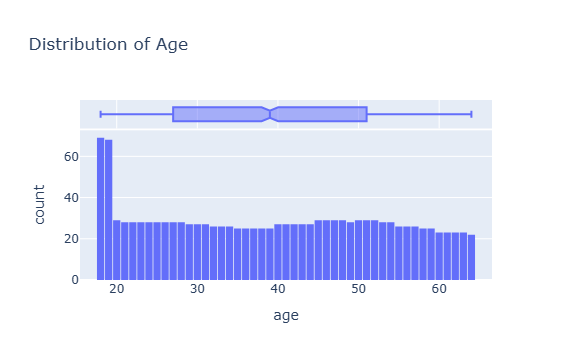

In [24]:

fig=px.histogram(medical_df,
                x='age',
                marginal='box',
                nbins=47,
                title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

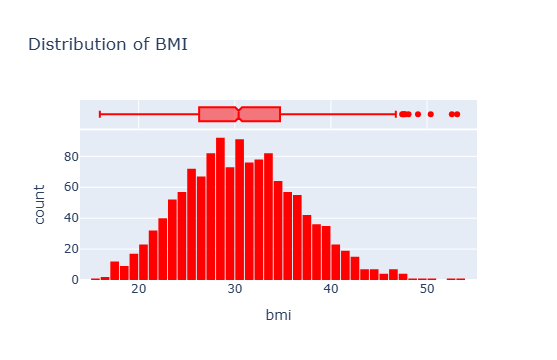

In [25]:
fig=px.histogram(medical_df,
                x='bmi',
                marginal='box',
                color_discrete_sequence=['red'],
                title='Distribution of BMI ')
fig.update_layout(bargap=0.1)
fig.show()

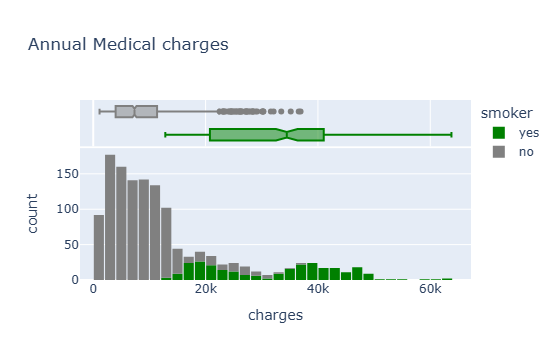

In [26]:
fig=px.histogram(medical_df,
                x='charges',
                marginal='box',
                 color='smoker',
                color_discrete_sequence=['green','grey'],
                title='Annual Medical charges')
fig.update_layout(bargap=0.1)
fig.show()

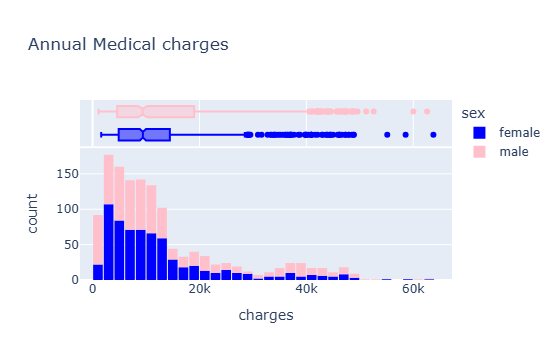

In [27]:
fig=px.histogram(medical_df,
                x='charges',
                marginal='box',
                 color='sex',
                color_discrete_sequence=['blue','pink'],
                title='Annual Medical charges')
fig.update_layout(bargap=0.1)
fig.show()

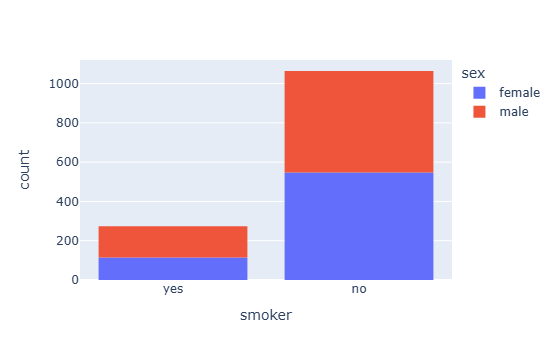

In [28]:
px.histogram(medical_df, x='smoker', color='sex')

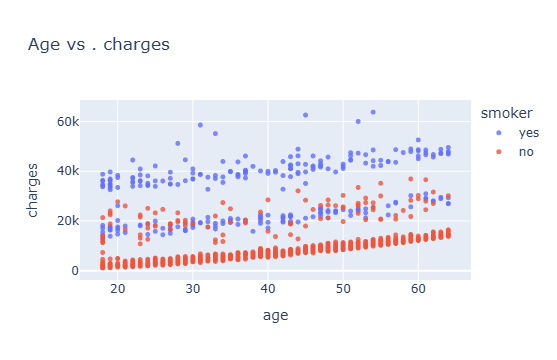

In [29]:
import plotly.express as px
fig = px.scatter(medical_df,
                x='age',
                y='charges',
                color='smoker',
                opacity=0.8,
                 hover_data={'sex'},
                 title='Age vs . charges'
                )
fig.update_traces(marker_size=5)
fig.show()

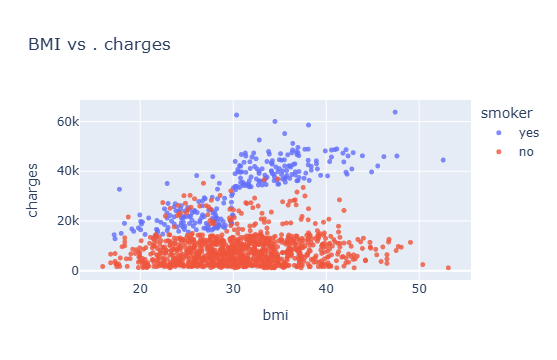

In [30]:
import plotly.express as px
fig = px.scatter(medical_df,
                x='bmi',
                y='charges',
                color='smoker',
                opacity=0.8,
                 hover_data={'sex'},
                 title='BMI vs . charges'
                )
fig.update_traces(marker_size=5)
fig.show()

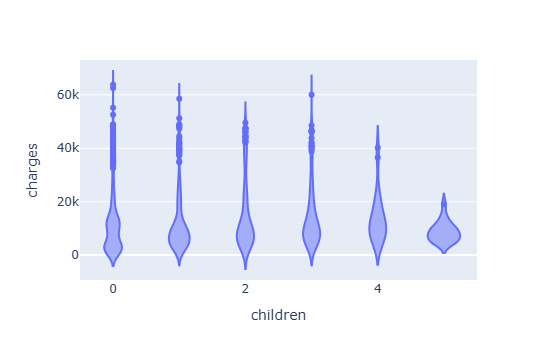

In [31]:
px.violin(medical_df, x='children',y='charges')

# Finding the Correlation

In [32]:
medical_df.charges.corr(medical_df.age)

np.float64(0.2990081933306476)

In [33]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362878)

In [34]:
smoker_values={'no':0,'yes':1}
smoker_numeric = medical_df.smoker.map(smoker_values)
smoker_numeric

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1338, dtype: int64

In [35]:
medical_df.charges.corr(medical_df.children)

np.float64(0.06799822684790469)

In [36]:
medical_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984782)

In [37]:
medical_df.select_dtypes(include='number').corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


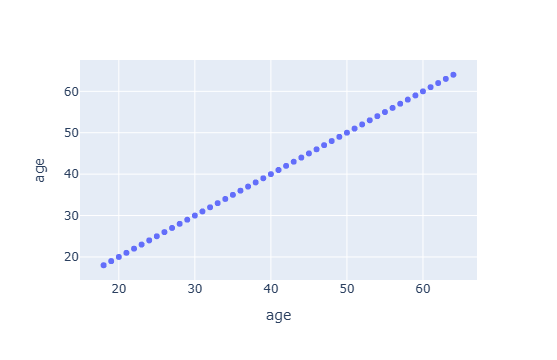

In [38]:
px.scatter(medical_df,x='age',y='age')

Text(0.5, 1.0, 'Correlation Matrix')

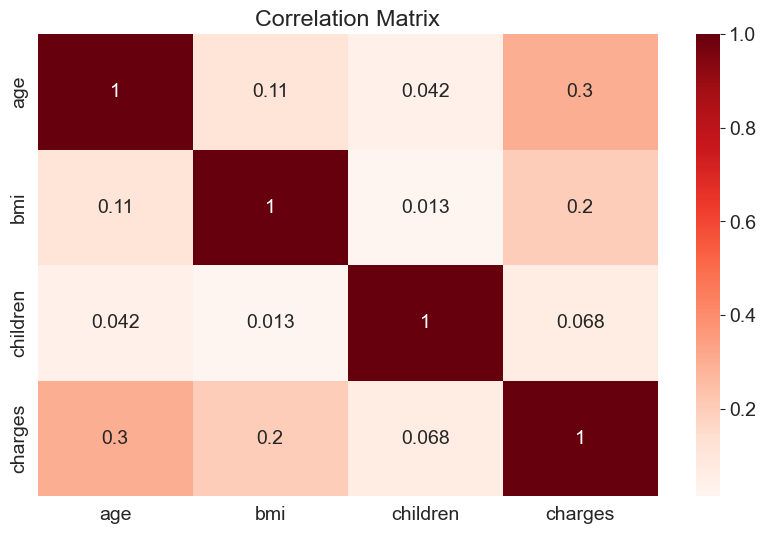

In [39]:
sns.heatmap(medical_df.corr(numeric_only=True), cmap='Reds', annot=True)
plt.title('Correlation Matrix')

# Linear Regression using a Single Feature


In [40]:
non_smoker_df=medical_df[medical_df.smoker =='no']

<Axes: title={'center': 'Age vs charges'}, xlabel='age', ylabel='charges'>

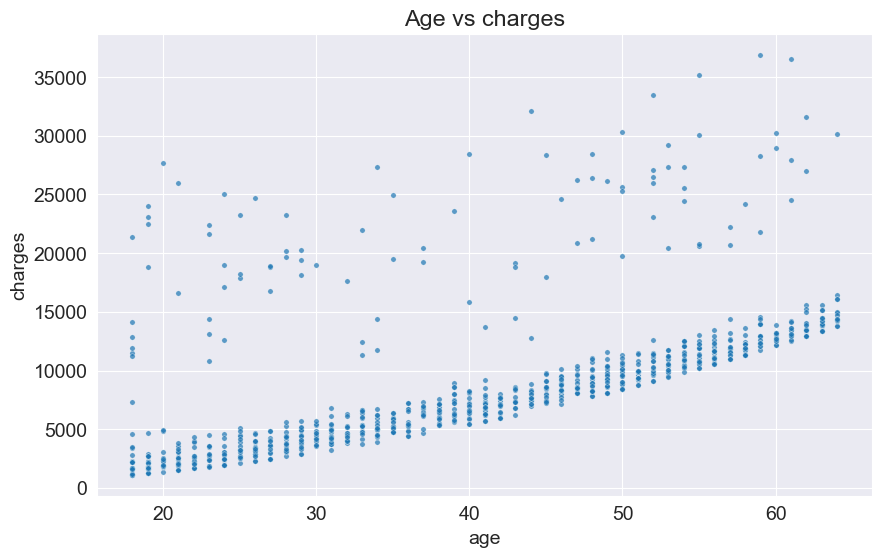

In [41]:
plt.title('Age vs charges')
sns.scatterplot(data=non_smoker_df,x='age',y='charges',alpha=0.7,s=15)

# Model

In [42]:
def estimate_charges(age, w ,b):
    return w*age*+b

In [43]:
w=50
b=100

In [44]:
ages=non_smoker_df.age
estimated_charges = estimate_charges(ages, w, b)
estimated_charges

1        90000
2       140000
3       165000
4       160000
5       155000
         ...  
1332    260000
1333    250000
1334     90000
1335     90000
1336    105000
Name: age, Length: 1064, dtype: int64

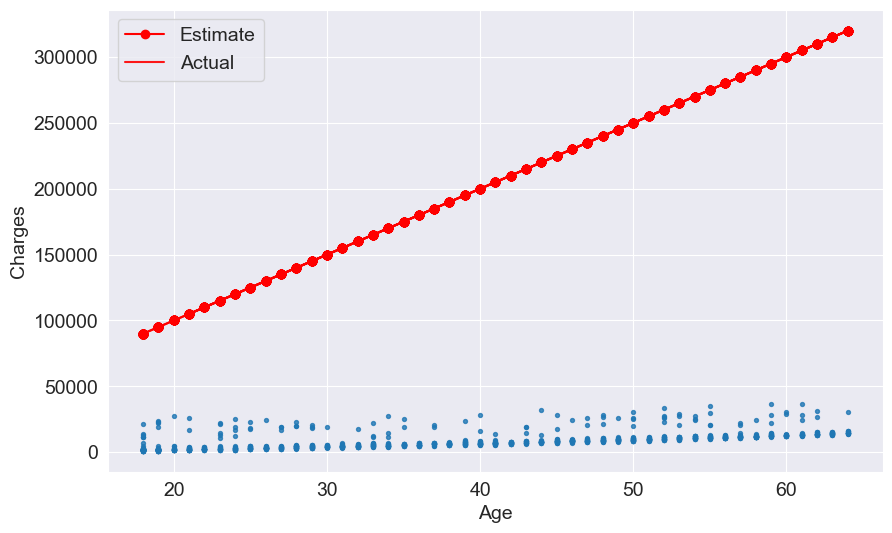

In [45]:
plt.plot(ages, estimated_charges, 'r-o');
plt.xlabel('Age');
plt.ylabel('Estimated Charges');target = non_smoker_df.charges

plt.plot(ages, estimated_charges, 'r', alpha=0.9);
plt.scatter(ages, target, s=8,alpha=0.8);
plt.xlabel('Age');
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual']);

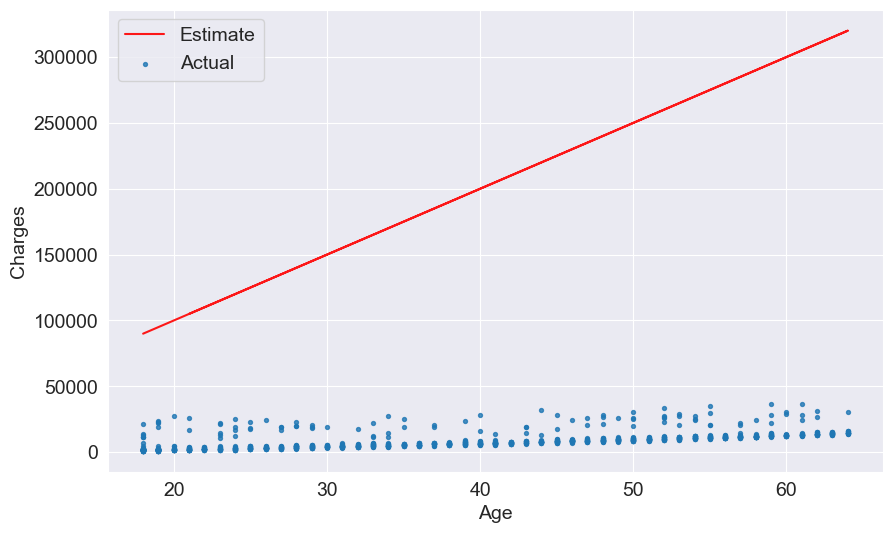

In [46]:
target = non_smoker_df.charges

plt.plot(ages, estimated_charges, 'r', alpha=0.9);
plt.scatter(ages, target, s=8,alpha=0.8);
plt.xlabel('Age');
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual']);

In [47]:

def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    
    estimated_charges = estimate_charges(ages, w, b)
    
    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

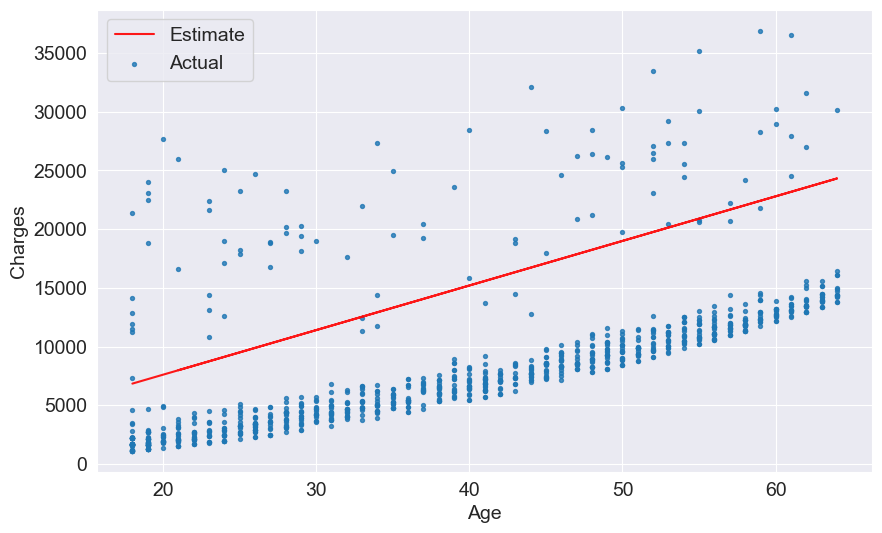

In [48]:
try_parameters(10,38)

# Loss/Cost Function


In [49]:
import numpy as np

In [57]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [58]:
w=50
b=100

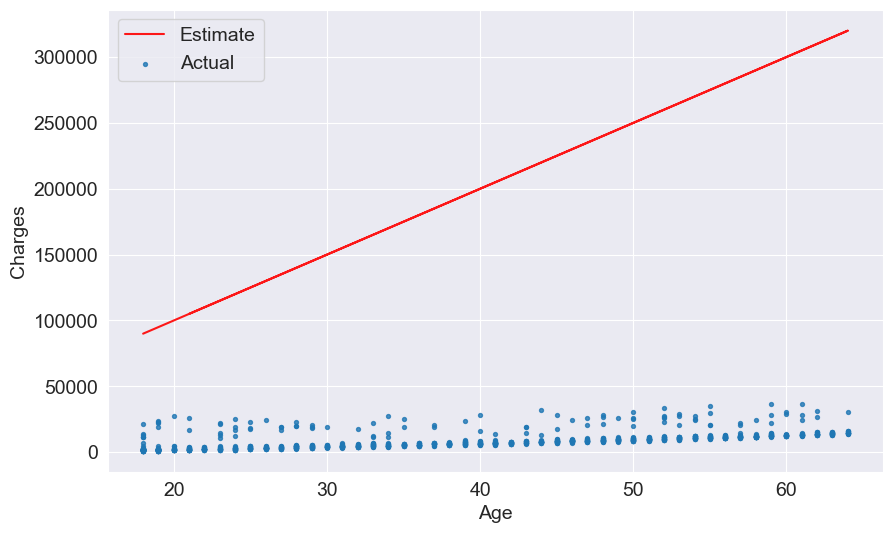

In [59]:
try_parameters(w,b)

In [60]:
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age, w, b)

In [61]:
rmse(targets, predicted)

np.float64(199974.03872448098)

In [62]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))


In [63]:
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age, w, b)

In [64]:


def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    predictions = estimate_charges(ages, w, b)
    
    plt.plot(ages, predictions, 'r', alpha=0.9)
    plt.scatter(ages, target, s=8, alpha=0.8)
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual'])
    
    loss = rmse(target, predictions)
    print("RMSE Loss: ", loss)

try_parameters(10, 20)

# Linear Regression using Scikit-learn


In [66]:
from sklearn.linear_model import LinearRegression

In [67]:
model = LinearRegression()

In [68]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [69]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print('inputs.shape:',inputs.shape)
print('targes.shape:', targets.shape)

inputs.shape: (1064, 1)
targes.shape: (1064,)


In [70]:
model.fit(inputs,targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [71]:
model.predict(np.array([[23],[37],[61]]))

C:\Users\omerk\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [72]:
predictions = model.predict(inputs)

In [73]:
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [74]:
rmse(targets, predictions)


np.float64(4662.505766636395)

In [75]:
model.coef_


array([267.24891283])

In [76]:
model.intercept_

np.float64(-2091.4205565650864)

RMSE Loss:  23386652.965478294


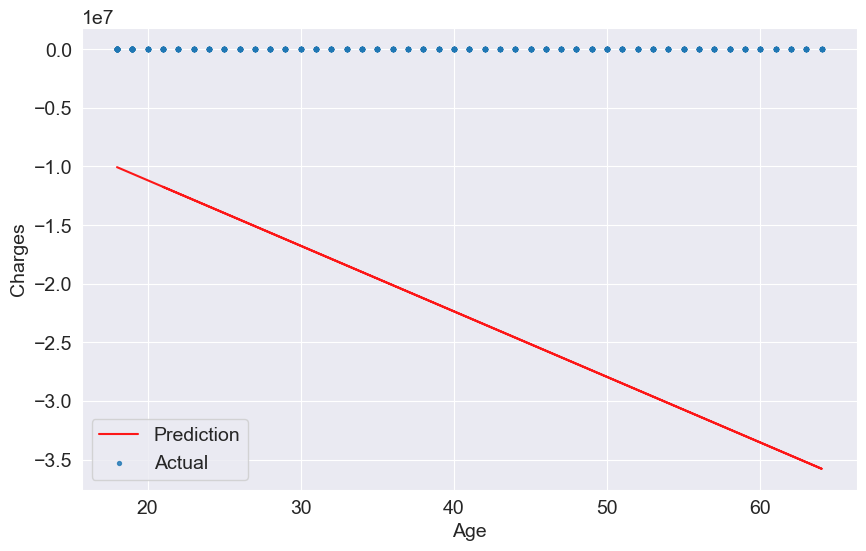

In [77]:

try_parameters(model.coef_, model.intercept_)


In [78]:
inputs, targets= non_smoker_df[['age','bmi']],non_smoker_df['charges']
model=LinearRegression().fit(inputs,targets)
predictions=model.predict(inputs)
loss=rmse(targets,predictions)
print('loss:', loss)

loss: 4662.3128354612945


In [79]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.0840365431283327)

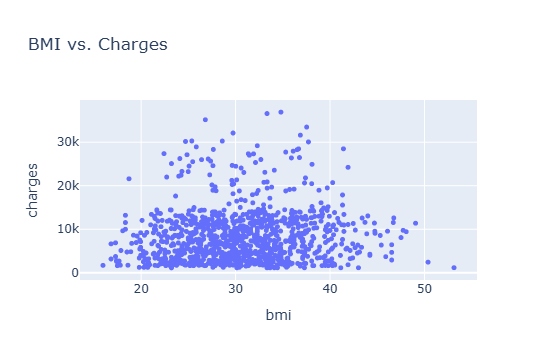

In [80]:
fig = px.scatter(non_smoker_df, x='bmi', y='charges', title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

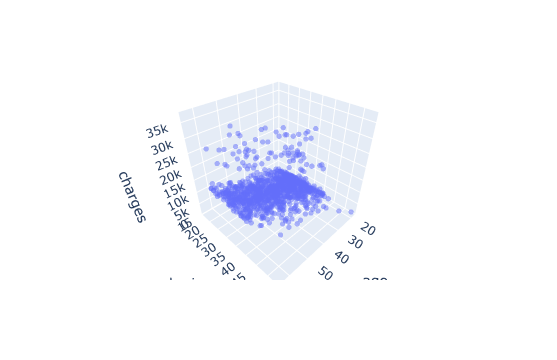

In [81]:
fig = px.scatter_3d(non_smoker_df, x='age', y='bmi', z='charges')
fig.update_traces(marker_size=3, marker_opacity=0.5)
fig.show()

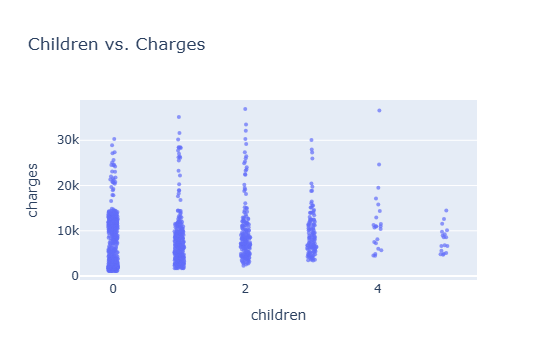

In [82]:
fig = px.strip(non_smoker_df, x='children', y='charges', title= "Children vs. Charges")
fig.update_traces(marker_size=4, marker_opacity=0.7)
fig.show()


# Linear Regression using Multiple Features


In [83]:
inputs,targets=non_smoker_df[['age','bmi','children']],non_smoker_df['charges']


In [84]:
model= LinearRegression().fit(inputs,targets)

In [85]:
predictions=model.predict(inputs)

In [86]:
loss=rmse(targets,predictions)
print('loss:',loss)

loss: 4608.470405038247


In [87]:
inputs,targets=medical_df[['age','bmi','children']],medical_df['charges']
model= LinearRegression().fit(inputs,targets)
predictions=model.predict(inputs)
loss=rmse(targets,predictions)
print('loss:',loss)

loss: 11355.317901125973


In [88]:
loss

np.float64(11355.317901125973)

In [89]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# A function to take input from user to Predicte the Insurance Cost 

In [90]:

import numpy as np
from sklearn.linear_model import LinearRegression


medical_df['smoker_num'] = medical_df['smoker'].map({'yes': 1, 'no': 0})


inputs = medical_df[['age', 'bmi', 'children', 'smoker_num']]
targets = medical_df['charges']


model = LinearRegression()
model.fit(inputs, targets)


def predict_insurance_cost():
    age = int(input("Enter age: "))
    bmi = float(input("Enter BMI: "))
    children = int(input("Enter number of children: "))
    smoker = input("Smoker? (yes/no): ").lower()

    smoker_num = 1 if smoker == 'yes' else 0

    data = [[age, bmi, children, smoker_num]]

    prediction = model.predict(data)

    print("Predicted Insurance Cost:", prediction)


predict_insurance_cost()

Enter age:  20
Enter BMI:  30.5
Enter number of children:  0
Smoker? (yes/no):  yes


C:\Users\omerk\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predicted Insurance Cost: [26682.0884026]
